<!--nav-->
> **Обучающая цепочка · 8/8.**  ·  ← [предыдущий](07_theory_ladder.ipynb)  
> *Чему учит:* контактные сценарии — штамп с профилем `z(x,y)` и взаимный контакт пары поверх КТН.

# 08 — Штамп и две пластины: контактные сценарии поверх КТН (§9.2)

Два дополнительных сценария нелинейного контакта МОР+КТН (веха N7), оба —
надстройка над тем же решателем `contact_nl`:

* **§1. Штамп** — препятствие с ПРОФИЛЕМ `z(x, y)` (не плоское). Условие
  Синьорини `u_c ≤ z` с переменным `z`: аргумент `gap` принимает массив по узлам
  квадратуры. Неплоский индентор ЛОКАЛИЗУЕТ зону контакта под собой.
* **§2. Две пластины** — взаимный контакт двух деформируемых тел: общая реакция
  `r` определяется СОВМЕСТНО (`f₁−r` / `f₂+r`, 3-й закон Ньютона), непроникание
  лицевых `u_c1 − u_c2 ≤ z`. Редукция: жёсткая 2-я пластина ⇒ односторонний
  контакт одной (гейт).

Каноническая пластина — защемлённый круг, неподвижная кромка, `h/L=0.2`.
Case-файл единой модели: `cases/ci/ktn_full_circle_clamped_uniform.toml`.

In [1]:
%matplotlib inline
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation

from plate_solver.config import Config
from plate_solver.contact_nl import NonlinearContactMOR, NonlinearTwoPlateMOR
from plate_solver.diagnostics import contact_report
from plate_solver.geometry import make_circle
from plate_solver.ktn_solver import KTNSolver

nu, h = 0.3, 0.2
dom = make_circle(1.0)
cfg = Config(E=1.0, h=h, nu=nu, a=1.0, q0=0.01, p=10, Q=72,
             n_load_steps=3, karman_tol=1e-6, karman_max_iter=150,
             beta=1.5, max_iter=1200, tol=3e-4)


def solver(c=cfg):
    return KTNSolver.from_theory_name(dom, c, "ktn_full",
                                      bc_type="clamped", inplane_bc="immovable")

## 1. Штамп: препятствие с профилем `z(x, y)`

Индентор-параболоид с низшей точкой, СМЕЩЁННОЙ от центра в `x_c`: там зазор
наименьший, туда и стягивается контакт. Сравниваем с плоским зазором той же
высоты `z₀` — плоский даёт зону у центра, профиль локализует её под индентором
(меньше узлов, выше пик реакции).

In [2]:
s = solver()
q = s.quad
w_free = s.solve_uniform().w_max
xc, z0 = 0.45, 0.45 * w_free
gap_prof = z0 + 3.0 * w_free * ((q.x - xc) ** 2 + q.y ** 2)   # параболоид, низ в (xc,0)

r_prof = NonlinearContactMOR(s, cfg, gap=gap_prof, scheme="merged").solve()
r_flat = NonlinearContactMOR(s, cfg, gap=z0, scheme="merged").solve()

for name, res in (("плоский z₀", r_flat), ("штамп z(x,y)", r_prof)):
    rep = contact_report(res.r_nodes, q)
    print(f"{name:<14}: n_contact={rep['n_contact']:>3}  пятен={rep['n_components']}  "
          f"пик=({rep['peak_xy'][0]:+.2f},{rep['peak_xy'][1]:+.2f})  r_max={rep['r_max']:.3e}")
print(f"\nиндентор смещён в x_c={xc}: зона штампа стянута к нему, зона уже плоской")

плоский z₀    : n_contact=108  пятен=1  пик=(+0.15,+0.15)  r_max=4.349e-02
штамп z(x,y)  : n_contact= 12  пятен=1  пик=(+0.28,+0.02)  r_max=2.714e-01

индентор смещён в x_c=0.45: зона штампа стянута к нему, зона уже плоской


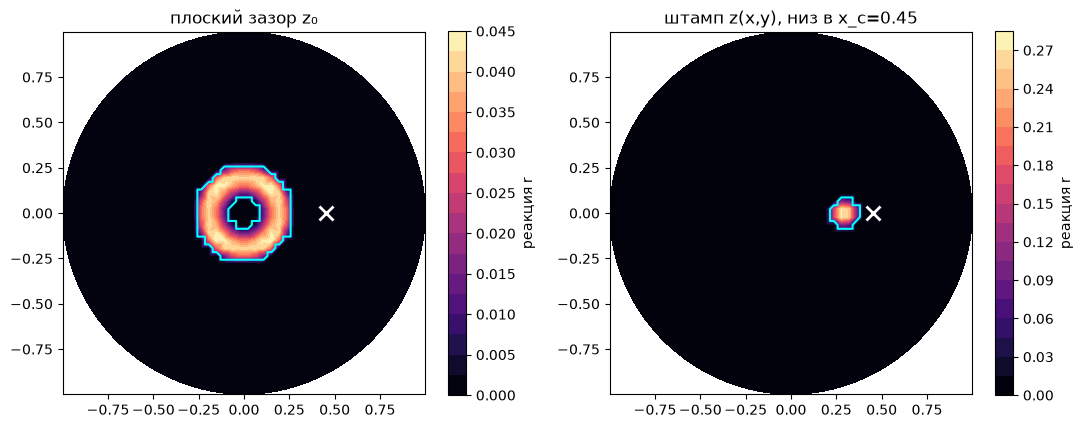

голубой контур — граница зоны контакта; белый × — низшая точка индентора


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
tri = Triangulation(q.x, q.y)
for ax, (name, res) in zip(axes, (("плоский зазор z₀", r_flat),
                                   ("штамп z(x,y), низ в x_c=0.45", r_prof)), strict=True):
    cs = ax.tricontourf(tri, res.r_nodes, levels=18, cmap="magma")
    ax.tricontour(tri, res.contact_mask.astype(float), levels=[0.5],
                  colors="cyan", linewidths=1.5)
    ax.plot(0.45, 0.0, "wx", ms=10, mew=2)
    fig.colorbar(cs, ax=ax, shrink=0.85, label="реакция r")
    ax.set_aspect("equal")
    ax.set_title(name)
plt.tight_layout()
plt.show()
print("голубой контур — граница зоны контакта; белый × — низшая точка индентора")

## 2. Две пластины: взаимный контакт

Две деформируемые пластины с начальным зазором `z`; нижняя нагружена, верхняя —
нет (её двигает только реакция). Реакция `r ≥ 0` определяется СОВМЕСТНО: нижняя
несёт `f₁ − r`, верхняя `f₂ + r` (3-й закон Ньютона), непроникание лицевых
`u_c1 − u_c2 ≤ z`. Общая квадратура (одна область, один `Q`).

In [4]:
s1, s2 = solver(), solver()                     # две одинаковые пластины
gap = 0.4 * s1.solve_uniform().w_max
two = NonlinearTwoPlateMOR(s1, s2, cfg, gap=gap, f2=0.0).solve()
print(f"взаимный контакт: r_max={two.r_max:.3e}  n_contact={two.n_contact}  "
      f"пятен={two.n_components}  сошлось={two.converged}")
print(f"прогибы: w1_max={two.w1_max:.4f} (нагружена)  w2_max={two.w2_max:.4f} "
      f"(отклик на реакцию)  зазор z={gap:.4f}")
print(f"размягчение 1-й реакцией: w1_max={two.w1_max:.4f} < свободное "
      f"{s1.solve_uniform().w_max:.4f}")

# редукция-гейт: жёсткая 2-я пластина ⇒ односторонний контакт одной
s2_rigid = solver(replace(cfg, E=1000.0))
single = NonlinearContactMOR(s1, cfg, gap=gap, scheme="merged").solve()
two_rigid = NonlinearTwoPlateMOR(s1, s2_rigid, cfg, gap=gap, f2=0.0).solve()
print(f"\nредукция (2-я в 1000× жёстче): w1_max={two_rigid.w1_max:.5f} ≈ одиночный "
      f"{single.w_max:.5f}  (|Δ|/w={abs(two_rigid.w1_max-single.w_max)/single.w_max:.1e})")

взаимный контакт: r_max=2.097e-02  n_contact=116  пятен=1  сошлось=False
прогибы: w1_max=0.1200 (нагружена)  w2_max=0.0589 (отклик на реакцию)  зазор z=0.0614
размягчение 1-й реакцией: w1_max=0.1200 < свободное 0.1535



редукция (2-я в 1000× жёстче): w1_max=0.06127 ≈ одиночный 0.06112  (|Δ|/w=2.4e-03)


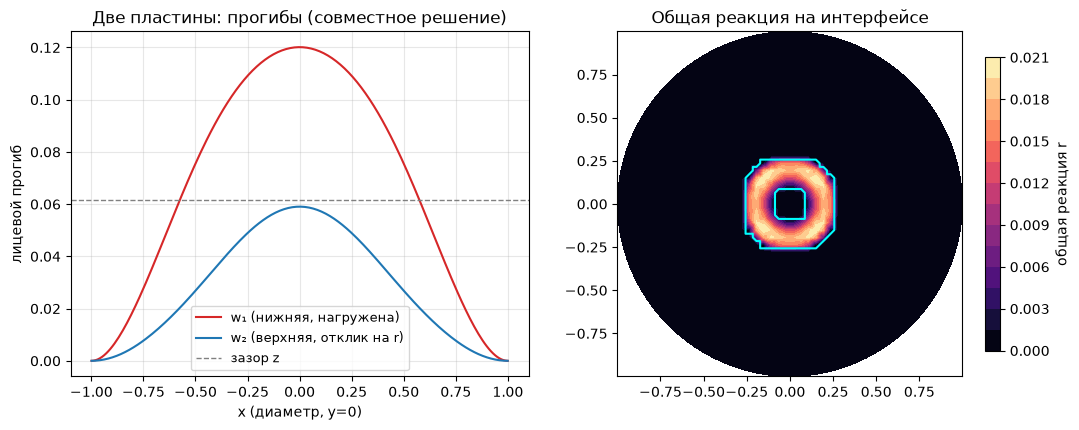

In [5]:
xs = np.linspace(-0.999, 0.999, 200)
ys = np.zeros_like(xs)
w1 = s1.deflection(two.cw1, xs, ys)
w2 = s2.deflection(two.cw2, xs, ys)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))
axL.plot(xs, w1, "-", color="tab:red", label="w₁ (нижняя, нагружена)")
axL.plot(xs, w2, "-", color="tab:blue", label="w₂ (верхняя, отклик на r)")
axL.axhline(gap, ls="--", color="gray", lw=1, label="зазор z")
axL.set_xlabel("x (диаметр, y=0)")
axL.set_ylabel("лицевой прогиб")
axL.set_title("Две пластины: прогибы (совместное решение)")
axL.legend(fontsize=9)
axL.grid(alpha=0.3)

tri = Triangulation(s1.quad.x, s1.quad.y)
cs = axR.tricontourf(tri, two.r_nodes, levels=18, cmap="magma")
axR.tricontour(tri, two.contact_mask.astype(float), levels=[0.5],
               colors="cyan", linewidths=1.5)
fig.colorbar(cs, ax=axR, shrink=0.85, label="общая реакция r")
axR.set_aspect("equal")
axR.set_title("Общая реакция на интерфейсе")
plt.tight_layout()
plt.show()

## 3. Итог

Оба сценария §9.2 — надстройка над `contact_nl` без нового ядра:

* **штамп** — переменное `z(x, y)` (поле `gap`) локализует зону под индентором;
  подтверждает, что уточнённая теория не терпит точечных концентраций (реакция
  сглажена лицевой кривизной);
* **две пластины** (`NonlinearTwoPlateMOR`) — совместная реакция двух КТН-решателей;
  редукция к одностороннему контакту при жёсткой второй пластине — гейт
  корректности.

Питает завершающие сценарии; ядро (единая модель + односторонний контакт МОР+КТН)
не затронуто.